# FIE463 - Group Term Paper 1

In [1]:
# Libraries
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

## Part 1

In [2]:
# 1. Parameters
@dataclass
class Parameters:
    """
    Model parameters
    """

    beta: float = .99**30           # Discount factor
    gamma: float = 2.1              # Relative risk aversion
    tau: float = .3                 # Payroll tax rate
    phi: float = .5                 # Fraction of wealth bequeathed by old capitalists
    alpha: float = .36              # Capital share in production
    delta: float = 1 - .94**30      # Capital depreciation rate
    z: float = 1.0                  # Total factor productivity
    N_w: float = .8                 # Fraction of workers
    N_k: float = .2                 # Fraction of capitalists

In [3]:
# Parameter instance
par = Parameters()

In [4]:
# Interim function to compute prices, labor, capital-labor ratio given capital stock K
def compute_prices(K, par:Parameters):
    """
    Compute prices given capital level K.
    These are derived from the firm's first order conditions.
    """
    # Labor supply
    L = .5 * par.N_w

    # Capital-labor ratio
    k = K / L
    # Wage
    w = (1 - par.alpha) * par.z * k**par.alpha

    # Interest rate
    r = par.alpha * par.z * k**(par.alpha - 1) - par.delta

    return L, k, w, r

In [5]:
# 2. Euler error function
def euler_err(K_next, K, par: Parameters):
    """
    Compute the capitalists' Euler equation error for a given capital stock today and tomorrow
    """
    # Wage and rate from Cobb-Douglas production function - This period and next
    L, k, w, r = compute_prices(K, par)
    L_next, k_next, w_next, r_next = compute_prices(K_next, par)

    # Asset market clearing (pre means t-1)
    a_pre = K / (.5 * par.N_k)
    a_t = K_next / (.5 * par.N_k)

    # Intergenerational transfer
    b_t = par.phi * (1 + r) * a_pre

    # Euler error consumption values
    c_ky = b_t - a_t                                # Consumption of young capitalists
    c_ko = (1 - par.phi) * (1 + r_next) * a_t       # Consumption of old capitalists

    # Guard against invalid consumption (Might happen at to large K and K_next)
    if c_ky <= 0 or c_ko <= 0:
        # Large positive error: root-finders will avoid this region
        return 1e6
    # This didn't really help, consider removing. Choosing a good grid is more important.


    # Euler error (LHS - RHS)
    euler_error = c_ky**(-par.gamma) - par.beta * (1 - par.phi) * (1 + r_next) * c_ko**(-par.gamma)

    return euler_error

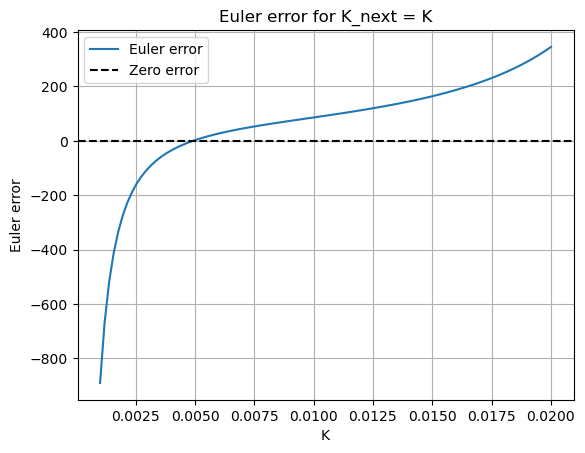

In [6]:
# 3. Plot euler error for a grid of capital levels K to verify that the function has a root, assuming K_(t+1) = K_t
K_grid = np.linspace(0.001, 0.02, 100)
# Values of K on this grid are very small, but that follows from large delta and 30-year periods.
euler_errors = [euler_err(K, K, par) for K in K_grid]

plt.plot(K_grid, euler_errors, label='Euler error')
plt.axhline(0, color='k', linestyle='--', label='Zero error')
plt.xlabel('K')
plt.ylabel('Euler error')
plt.title('Euler error for K_next = K')
plt.legend()
_ = plt.grid()

Root seems to sit around or at K = 0.0050

... Explain why larger grid is problematic in this model ...

## Part 2

In [7]:
# 1. Define dataclass for steady state values
@dataclass
class SteadyState:
    """Steady state values...
    """
    par: Parameters = None         # Parameters to compute equilibrium
    K: float = None                # Steady-state aggregate capital
    L: float = None                # Steady-state labor supply
    k: float = None                # Steady-state capital-labor ratio
    w: float = None                # Steady-state wage
    r: float = None                # Steady-state interest rate
    Y: float = None                # Steady-state output
    c_wy: float = None             # Steady-state consumption of young workers
    c_wo: float = None             # Steady-state consumption of old workers
    a: float = None                # Steady-state asset holdings per young capitalist
    b: float = None                # Steady-state bequests per young capitalist
    c_ky: float = None             # Steady-state consumption of young capitalists
    c_ko: float = None             # Steady-state consumption of old capitalists
    s: float = None                # Steady-state savings rate

In [8]:
# 2. Function to compute the steady state
def compute_steady_state(par: Parameters):
    """
    Compute the steady state of the model given parameters.
    """
    # Bracket for root finding, based on the plot of Euler errors
    bracket = (0.001, 0.02)  
    # Find the root of the Euler error function
    result = root_scalar(
        lambda K: euler_err(K, K, par),  # K_next = K for steady state
        bracket=bracket, 
        method='bisect')
    
    # Check if root finding was successful
    if not result.converged:
        raise ValueError("Root finding did not converge. Try adjusting the bracket or check the Euler error function.")
    
    K_star = result.root 

    # SteadyState instance to store results
    eq = SteadyState(par=par, K=K_star)

    # Compute prices and other variables at the steady state
    eq.L, eq.k, eq.w, eq.r = compute_prices(eq.K, par)
    eq.Y = par.z * eq.K**par.alpha * (eq.L)**(1 - par.alpha)
    eq.c_wy = (1 - par.tau) * eq.w
    eq.c_wo = par.tau * eq.w
    eq.a = eq.K / (.5 * par.N_k)
    eq.b = par.phi * (1 + eq.r) * eq.a
    eq.c_ky = eq.b - eq.a
    eq.c_ko = (1 + eq.r) * eq.a - eq.b
    eq.s = eq.a / eq.b

    return eq

In [9]:
# 3. Compute and print the steady state
eq = compute_steady_state(par)

# Print output, capital, factor prices, and consumption of each type (Improve later)
print(f'Steady-state output (Y): {eq.Y:.4f}')
print(f'Steady-state capital (K): {eq.K:.4f}')
print(f'Steady-state wage (w): {eq.w:.4f}')
print(f'Steady-state interest rate (r): {eq.r:.4%}')
print(f'Steady-state consumption of young workers (c_wy): {eq.c_wy:.4f}')
print(f'Steady-state consumption of old workers (c_wo): {eq.c_wo:.4f}')
print(f'Steady-state consumption of young capitalists (c_ky): {eq.c_ky:.4f}')
print(f'Steady-state consumption of old capitalists (c_ko): {eq.c_ko:.4f}')
print(f'Steady-state savings rate (s): {eq.s:.4f}')

# 4. Annualized interest rate to sanity-check results
r_annual = (1 + eq.r)**(1/30) - 1
print(f'Annualized interest rate: {r_annual:.4%}')

Steady-state output (Y): 0.0821
Steady-state capital (K): 0.0049
Steady-state wage (w): 0.1314
Steady-state interest rate (r): 516.2944%
Steady-state consumption of young workers (c_wy): 0.0920
Steady-state consumption of old workers (c_wo): 0.0394
Steady-state consumption of young capitalists (c_ky): 0.1025
Steady-state consumption of old capitalists (c_ko): 0.1517
Steady-state savings rate (s): 0.3245
Annualized interest rate: 6.2493%


## Part 3

In [10]:
# 1. Create Simulation dataclass to store time paths of variables
@dataclass
class Simulation:
    par: Parameters                 # Model Parameters
    T: int                          # Number of periods to simulate
    
    K_path: np.ndarray
    r_path: np.ndarray
    w_path: np.ndarray
    Y_path: np.ndarray
    c_wy_path: np.ndarray
    c_wo_path: np.ndarray
    a_path: np.ndarray
    b_path: np.ndarray
    c_ky_path: np.ndarray
    c_ko_path: np.ndarray
    s_path: np.ndarray              # Savings rate s = a/b

In [11]:
# 2. Function to simulate transition paths
def simulate_olg(K0, T, par: Parameters) -> Simulation:
    """
    Simulate the transition paths of the model starting from an initial capital stock K0 for T periods.
    """
    # allocate arrays
    K_path   = np.zeros(T)
    r_path   = np.zeros(T)
    w_path   = np.zeros(T)
    Y_path   = np.zeros(T)
    c_wy_path = np.zeros(T)
    c_wo_path = np.zeros(T)
    a_path    = np.zeros(T)
    b_path    = np.zeros(T)
    c_ky_path = np.zeros(T)
    c_ko_path = np.zeros(T)
    s_path    = np.zeros(T)

    # set initial capital
    K_path[0] = K0

    # simulate
    for t in range(T - 1):
        L, k, w, r = compute_prices(K_path[t], par)
        r_path[t] = r
        w_path[t] = w
        Y_path[t] = par.z * K_path[t]**par.alpha * L**(1 - par.alpha)
        c_wy_path[t] = (1 - par.tau) * w
        c_wo_path[t] = par.tau * w
        a_path[t] = K_path[t] / (0.5 * par.N_k)
        b_path[t] = par.phi * (1 + r) * a_path[t]
        c_ky_path[t] = b_path[t] - a_path[t]
        c_ko_path[t] = (1 + r) * a_path[t] - b_path[t]
        s_path[t] = a_path[t] / b_path[t]

        # Checking goods market clearing inside loop
        lhs = Y_path[t] + (1 - par.delta) * K_path[t]
        rhs = 0.5 * par.N_w * (c_wy_path[t] + c_wo_path[t]) \
        + 0.5 * par.N_k * (c_ky_path[t] + c_ko_path[t] + a_path[t])
        # Prints only if there is a mismatch
        if abs(lhs - rhs) > 1e-8:
            print(f"Goods market mismatch at t={t}: {lhs - rhs}")

        # root for K_{t+1}
        result = root_scalar(
            lambda K_next: euler_err(K_next, K_path[t], par),
            bracket=(0.001, 0.02),
            method='bisect'
        )
        if not result.converged:
            raise ValueError(f"Root finding did not converge at time {t}.")
        K_path[t+1] = result.root

    # last period
    L, k, w, r = compute_prices(K_path[T-1], par)
    r_path[T-1] = r
    w_path[T-1] = w
    Y_path[T-1] = par.z * K_path[T-1]**par.alpha * L**(1 - par.alpha)
    c_wy_path[T-1] = (1 - par.tau) * w
    c_wo_path[T-1] = par.tau * w
    a_path[T-1] = K_path[T-1] / (0.5 * par.N_k)
    b_path[T-1] = par.phi * (1 + r) * a_path[T-1]
    c_ky_path[T-1] = b_path[T-1] - a_path[T-1]
    c_ko_path[T-1] = (1 + r) * a_path[T-1] - b_path[T-1]
    s_path[T-1] = a_path[T-1] / b_path[T-1]

    # build Simulation object
    sim = Simulation(
        par=par, T=T,
        K_path=K_path, r_path=r_path, w_path=w_path, Y_path=Y_path,
        c_wy_path=c_wy_path, c_wo_path=c_wo_path,
        a_path=a_path, b_path=b_path,
        c_ky_path=c_ky_path, c_ko_path=c_ko_path,
        s_path=s_path
    )
    return sim

In [12]:
# 3. Verify by starting at half the steady-state capital
eq = compute_steady_state(par)
K0 = eq.K / 2  # Start with half of the steady-state capital to see a transition

sim = simulate_olg(K0, T=20, par=par)
print("Simulated capital path:", sim.K_path)

Simulated capital path: [0.00246113 0.00352527 0.0041906  0.0045546  0.00474127 0.00483405
 0.00487949 0.00490157 0.00491226 0.00491744 0.00491993 0.00492114
 0.00492172 0.00492201 0.00492214 0.00492221 0.00492224 0.00492225
 0.00492226 0.00492227]


In [13]:
def plot_simulation(eq: SteadyState, sim: Simulation):
    """
    Plot selected transition paths of the OLG model.

    Parameters
    ----------
    eq : SteadyState
        Initial steady state.
    sim : Simulation
        Simulation containing the time paths.
    """
    # Initialize 5-by-2 subplots
    fig, ax = plt.subplots(5, 2, figsize=(15, 12))

    # Define variables and their titles for plotting
    # Variables defined as list of tuples of (time series, title, steady-state value, plot as % deviation)
    variables = [
        (sim.Y_path,   'Output $Y_t$', eq.Y, True),
        (sim.K_path,   'Capital $K_t$', eq.K, True),
        (sim.w_path,   'Wage $w_t$', eq.w, True),
        (sim.r_path,   'Interest rate $r_t$', eq.r, False),
        (sim.b_path,   'Bequests per young capitalist $b_t$', eq.b, True),
        (sim.s_path,   'Savings rate $s_t$', eq.s, False),
        (sim.c_wy_path, 'Young workers consumption $c^w_{y,t}$', eq.c_wy, True),
        (sim.c_wo_path, 'Old workers consumption $c^w_{o,t}$', eq.c_wo, True),
        (sim.c_ky_path, 'Young capitalists consumption $c^k_{y,t}$', eq.c_ky, True),
        (sim.c_ko_path, 'Old capitalists consumption $c^k_{o,t}$', eq.c_ko, True),
    ]

    # Time grid for x-axis
    T = sim.T
    tgrid = np.arange(T)

    # Plot each variable with its steady-state reference line
    for i, (series, title, ss_value, as_pct_dev) in enumerate(variables):
        row, col = divmod(i, 2)
        
        # Evaluate whether to plot as percent deviation or percent for s and r (by True or False in variables list)
        if as_pct_dev:
            # Plot as percent deviation from steady state
            pct_dev = 100 * (series - ss_value) / ss_value
            ax[row, col].plot(tgrid, pct_dev, marker='o')
            ax[row, col].axhline(0, color='orange', linestyle='--', linewidth=1)
            ax[row, col].set_ylabel('% deviation from SS')
        else:
            # Plot in percent
            ax[row, col].plot(tgrid, 100 * series, marker='o')
            ax[row, col].axhline(100 * ss_value, color='orange', linestyle='--', linewidth=1)
            ax[row, col].set_ylabel('Percent (%)')
        
        # Set titles and labels
        ax[row, col].set_title(title)
        ax[row, col].set_xlabel('Time')
        ax[row, col].grid(True)

    plt.tight_layout()
    plt.show()

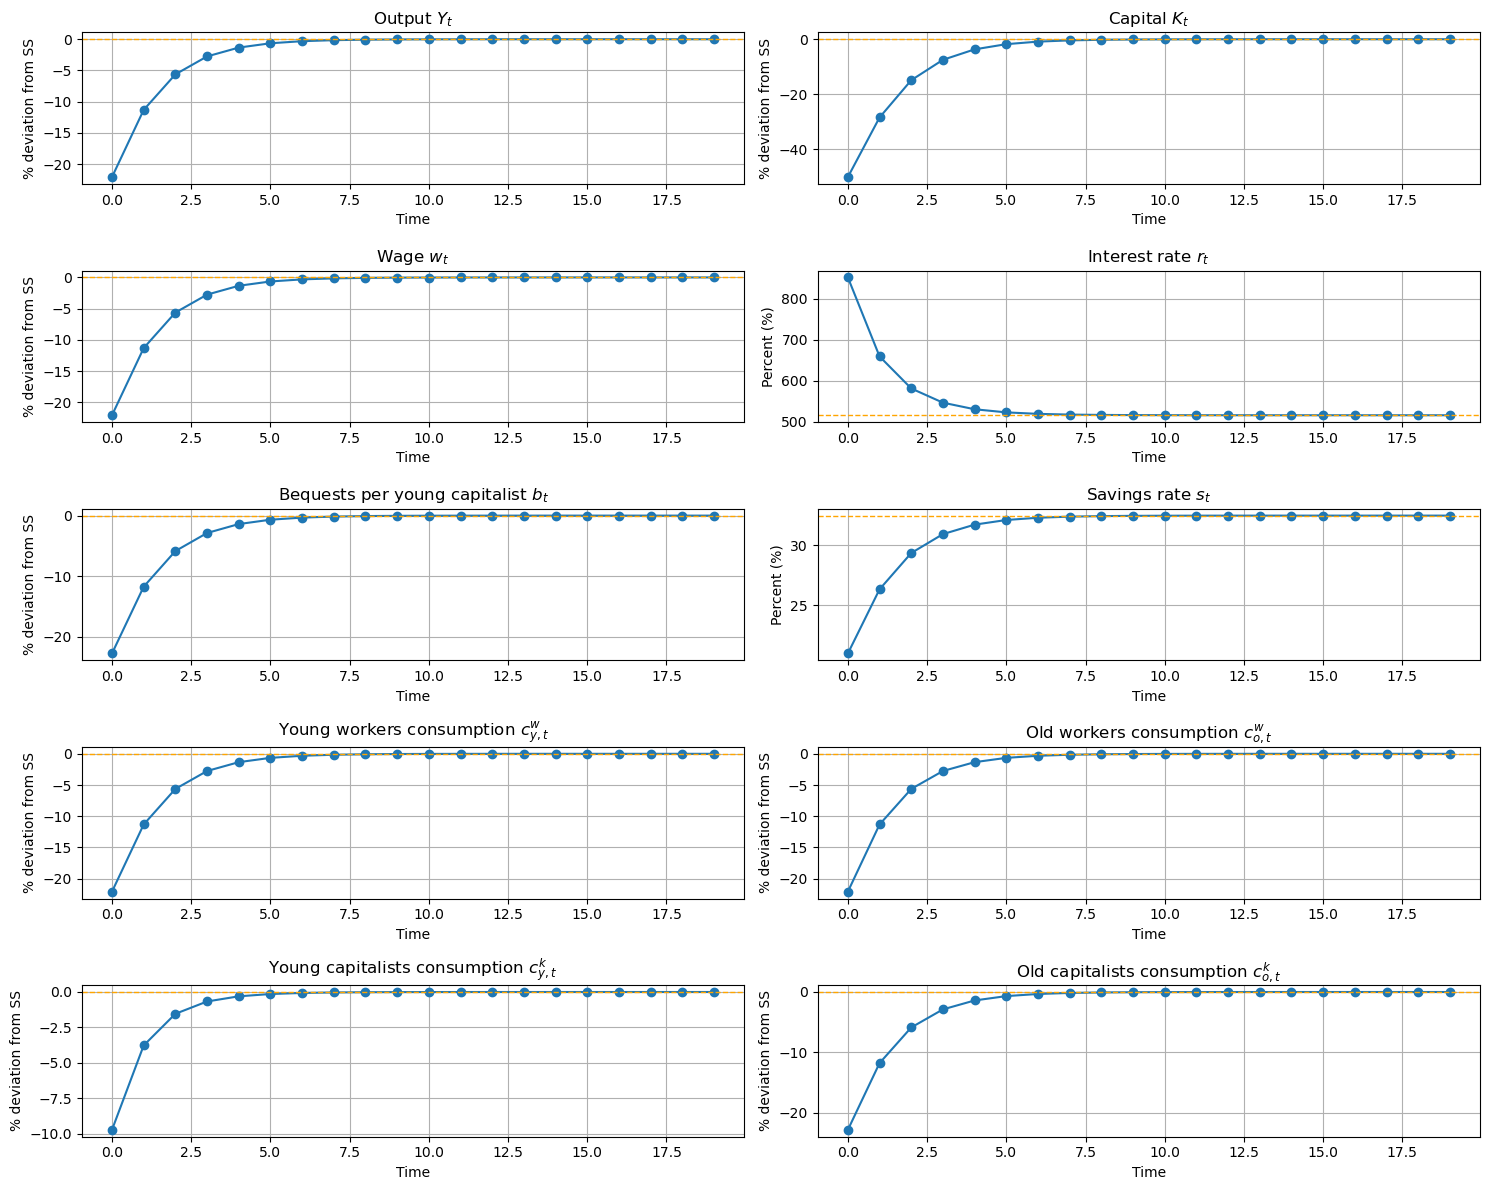

In [14]:
eq = compute_steady_state(par)
K0 = .5 * eq.K

plot_simulation(eq, simulate_olg(K0, T=20, par=par))

## Part 4

In [15]:
# 1. Update parameters to add wealth tax rate of 0.05
@dataclass
class Parameters:
    """
    Model parameters
    """

    beta: float = .99**30           # Discount factor
    gamma: float = 2.1              # Relative risk aversion
    tau: float = .3                 # Payroll tax rate
    phi: float = .5                 # Fraction of wealth bequeathed by old capitalists
    alpha: float = .36              # Capital share in production
    delta: float = 1 - .94**30      # Capital depreciation rate
    z: float = 1.0                  # Total factor productivity
    N_w: float = .8                 # Fraction of workers
    N_k: float = .2                 # Fraction of capitalists
    tau_w: float = 0.05             # Wealth tax rate on capitalists' wealth (new parameter)

In [16]:
par = Parameters()

In [17]:
# 2. Update functions to account for wealth tax
def euler_err(K_next, K, par: Parameters):
    """
    Compute the capitalists' Euler equation error for a given capital stock today and tomorrow
    """
    # Wage and rate from Cobb-Douglas production function - This period and next
    L, k, w, r = compute_prices(K, par)
    L_next, k_next, w_next, r_next = compute_prices(K_next, par)

    # Asset market clearing (pre means t-1)
    a_pre = K / (.5 * par.N_k)
    a_t = K_next / (.5 * par.N_k)

    # Transfers from wealth tax
    T_at = par.tau_w * (1 + r) * K
    T_at1 = par.tau_w * (1 + r_next) * K_next

    # Intergenerational transfer
    b_t = par.phi * (1 - par.tau_w) * (1 + r) * a_pre

    # Euler error consumption values
    c_ky = b_t + T_at- a_t                                                   # Consumption of young capitalists
    c_ko = (1 - par.phi) * (1 - par.tau_w) * (1 + r_next) * a_t + T_at1      # Consumption of old capitalists

    # Guard against invalid consumption (Might happen at to large K and K_next)
    if c_ky <= 0 or c_ko <= 0:
        # Large positive error: root-finders will avoid this region
        return 1e6
    # This didn't really help, consider removing. Choosing a good grid is more important.


    # Euler error (LHS - RHS)
    euler_error = c_ky**(-par.gamma) - par.beta * (1 + r_next) * (1 - par.tau_w) * (1 - par.phi) * c_ko**(-par.gamma)

    return euler_error

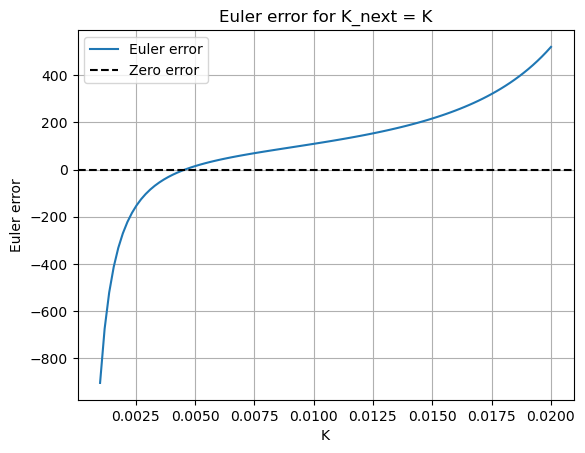

In [18]:
# Sanity-check
# 3. Plot euler error for a grid of capital levels K to verify that the function has a root, assuming K_(t+1) = K_t
K_grid = np.linspace(0.001, 0.02, 100)
# Values of K on this grid are very small, but that follows from large delta and 30-year periods.
euler_errors = [euler_err(K, K, par) for K in K_grid]

plt.plot(K_grid, euler_errors, label='Euler error')
plt.axhline(0, color='k', linestyle='--', label='Zero error')
plt.xlabel('K')
plt.ylabel('Euler error')
plt.title('Euler error for K_next = K')
plt.legend()
_ = plt.grid()

In [19]:
# 1. Define dataclass for steady state values
@dataclass
class SteadyState:
    """Steady state values...
    """
    par: Parameters = None         # Parameters to compute equilibrium
    K: float = None                # Steady-state aggregate capital
    L: float = None                # Steady-state labor supply
    k: float = None                # Steady-state capital-labor ratio
    w: float = None                # Steady-state wage
    r: float = None                # Steady-state interest rate
    Y: float = None                # Steady-state output
    c_wy: float = None             # Steady-state consumption of young workers
    c_wo: float = None             # Steady-state consumption of old workers
    a: float = None                # Steady-state asset holdings per young capitalist
    b: float = None                # Steady-state bequests per young capitalist
    c_ky: float = None             # Steady-state consumption of young capitalists
    c_ko: float = None             # Steady-state consumption of old capitalists
    s: float = None                # Steady-state savings rate
    T_a: float = None              # Steady-state wealth tax transfer

In [20]:
# Compute steady-state
# 2. Function to compute the steady state
def compute_steady_state(par: Parameters):
    """
    Compute the steady state of the model given parameters.
    """
    # Bracket for root finding, based on the plot of Euler errors
    bracket = (0.001, 0.02)  
    # Find the root of the Euler error function
    result = root_scalar(
        lambda K: euler_err(K, K, par),  # K_next = K for steady state
        bracket=bracket, 
        method='bisect')
    
    # Check if root finding was successful
    if not result.converged:
        raise ValueError("Root finding did not converge. Try adjusting the bracket or check the Euler error function.")
    
    K_star = result.root 

    # SteadyState instance to store results
    eq = SteadyState(par=par, K=K_star)

    # Compute prices and other variables at the steady state
    eq.L, eq.k, eq.w, eq.r = compute_prices(eq.K, par)
    eq.Y = par.z * eq.K**par.alpha * (eq.L)**(1 - par.alpha)
    eq.T_a = par.tau_w * (1 + eq.r) * eq.K
    eq.c_wy = (1 - par.tau) * eq.w + eq.T_a
    eq.c_wo = par.tau * eq.w + eq.T_a
    eq.a = eq.K / (.5 * par.N_k)
    eq.b = par.phi * (1 + eq.r) * (1 - par.tau_w) * eq.a
    eq.c_ky = eq.b - eq.a + eq.T_a
    eq.c_ko = (1 + eq.r) * (1 - par.tau_w) * eq.a - eq.b + eq.T_a  
    eq.s = eq.a / (eq.b + eq.T_a)

    return eq

In [21]:
# 3. Compute and print the steady state
eq = compute_steady_state(par)

# Print output, capital, factor prices, and consumption of each type (Improve later)
print(f'Steady-state output (Y): {eq.Y:.4f}')
print(f'Steady-state capital (K): {eq.K:.4f}')
print(f'Steady-state wage (w): {eq.w:.4f}')
print(f'Steady-state interest rate (r): {eq.r:.4%}')
print(f'Steady-state consumption of young workers (c_wy): {eq.c_wy:.4f}')
print(f'Steady-state consumption of old workers (c_wo): {eq.c_wo:.4f}')
print(f'Steady-state consumption of young capitalists (c_ky): {eq.c_ky:.4f}')
print(f'Steady-state consumption of old capitalists (c_ko): {eq.c_ko:.4f}')
print(f'Steady-state wealth tax transfer (T_a): {eq.T_a:.4f}')
print(f'Steady-state savings rate (s): {eq.s:.4f}')

# 4. Annualized interest rate to sanity-check results
r_annual = (1 + eq.r)**(1/30) - 1
print(f'Annualized interest rate: {r_annual:.4%}')

Steady-state output (Y): 0.0800
Steady-state capital (K): 0.0046
Steady-state wage (w): 0.1280
Steady-state interest rate (r): 545.3349%
Steady-state consumption of young workers (c_wy): 0.0910
Steady-state consumption of old workers (c_wo): 0.0399
Steady-state consumption of young capitalists (c_ky): 0.0959
Steady-state consumption of old capitalists (c_ko): 0.1416
Steady-state wealth tax transfer (T_a): 0.0015
Steady-state savings rate (s): 0.3228
Annualized interest rate: 6.4125%


# Part 4 should NOT repeat function and dataclass calls

# Just adapt them where they are to work with and without wealth tax

# Running part 4 should only require a few lines

## Part 5

## Part 6